# 📊 Análise Exploratória de Dados — Fundos de Investimento CVM

## Objetivo
Explorar os dados públicos da CVM para entender o comportamento dos fundos de investimento brasileiros.

## Perguntas que vamos responder
- Quantos fundos existem e quais os tipos?
- Como está distribuído o patrimônio líquido?
- Como evoluiu a captação ao longo do tempo?
- Existem dados faltando?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
import requests
import os

url = "https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202401.zip"

os.makedirs("../data/raw", exist_ok=True)

print("Baixando dados da CVM...")
response = requests.get(url)

with open("../data/raw/inf_diario_fi_202401.zip", "wb") as f:
    f.write(response.content)

print("✅ Download concluído!")

Baixando dados da CVM...
✅ Download concluído!


In [4]:
import zipfile

with zipfile.ZipFile("../data/raw/inf_diario_fi_202401.zip", "r") as zip:
    zip.extractall("../data/raw/")

print("✅ Arquivo extraído!")

✅ Arquivo extraído!


In [5]:
df = pd.read_csv("../data/raw/inf_diario_fi_202401.csv", sep=";", encoding="latin1")

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 567834
Colunas: 10


,TP_FUNDO_CLASSE,CNPJ_FUNDO_CLASSE,ID_SUBCLASSE,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,FI,00.017.024/0001-53,NaN,2024-01-02,1136699.13,34.298860,1139708.10,0.0,0.0,1
1,FI,00.017.024/0001-53,NaN,2024-01-03,1137245.82,34.312303,1140154.80,0.0,0.0,1
2,FI,00.017.024/0001-53,NaN,2024-01-04,1137741.93,34.326023,1140610.71,0.0,0.0,1
3,FI,00.017.024/0001-53,NaN,2024-01-05,1138240.64,34.338221,1141016.02,0.0,0.0,1
4,FI,00.017.024/0001-53,NaN,2024-01-08,1138427.98,34.350495,1141423.89,0.0,0.0,1


In [6]:
df = df.drop(columns=["ID_SUBCLASSE"])
df["DT_COMPTC"] = pd.to_datetime(df["DT_COMPTC"])
df = df[df["TP_FUNDO_CLASSE"] == "FI"]

print(f"Shape final: {df.shape}")
print(f"Nulos:\n{df.isnull().sum()}")
print(f"Tipos:\n{df.dtypes}")

Shape final: (567548, 9)
Nulos:
TP_FUNDO_CLASSE      0
CNPJ_FUNDO_CLASSE    0
DT_COMPTC            0
VL_TOTAL             0
VL_QUOTA             0
VL_PATRIM_LIQ        0
CAPTC_DIA            0
RESG_DIA             0
NR_COTST             0
dtype: int64
Tipos:
TP_FUNDO_CLASSE                 str
CNPJ_FUNDO_CLASSE               str
DT_COMPTC            datetime64[us]
VL_TOTAL                    float64
VL_QUOTA                    float64
VL_PATRIM_LIQ               float64
CAPTC_DIA                   float64
RESG_DIA                    float64
NR_COTST                      int64
dtype: object


In [7]:
print(f"Total de registros: {len(df)}")
print(f"Fundos únicos: {df['CNPJ_FUNDO_CLASSE'].nunique()}")
print(f"Período: {df['DT_COMPTC'].min()} até {df['DT_COMPTC'].max()}")
print(f"\nTipos de fundo:")
print(df["TP_FUNDO_CLASSE"].value_counts())

Total de registros: 567548
Fundos únicos: 25960
Período: 2024-01-01 00:00:00 até 2024-01-31 00:00:00

Tipos de fundo:
TP_FUNDO_CLASSE
FI    567548
Name: count, dtype: int64


In [8]:
df.describe()

,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
count,567548,5.675480e+05,5.675480e+05,5.675480e+05,5.675480e+05,5.675480e+05,5.675480e+05
mean,2024-01-16 07:43:10.588284,4.258992e+08,2.149082e+04,4.247060e+08,2.423375e+06,2.230003e+06,9.633216e+02
min,2024-01-01 00:00:00,-8.298310e+08,-5.940935e+03,-3.743481e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024-01-09 00:00:00,1.563344e+07,1.214390e+00,1.554779e+07,0.000000e+00,0.000000e+00,1.000000e+00
50%,2024-01-17 00:00:00,4.333619e+07,2.136139e+00,4.324950e+07,0.000000e+00,0.000000e+00,2.000000e+00
75%,2024-01-24 00:00:00,1.540165e+08,2.520056e+01,1.532720e+08,0.000000e+00,0.000000e+00,1.500000e+01
max,2024-01-31 00:00:00,1.613959e+11,2.013671e+08,1.613956e+11,9.083470e+09,1.399587e+10,1.176607e+06
std,NaN,2.881012e+09,1.295737e+06,2.877990e+09,5.540263e+07,4.951425e+07,1.609639e+04


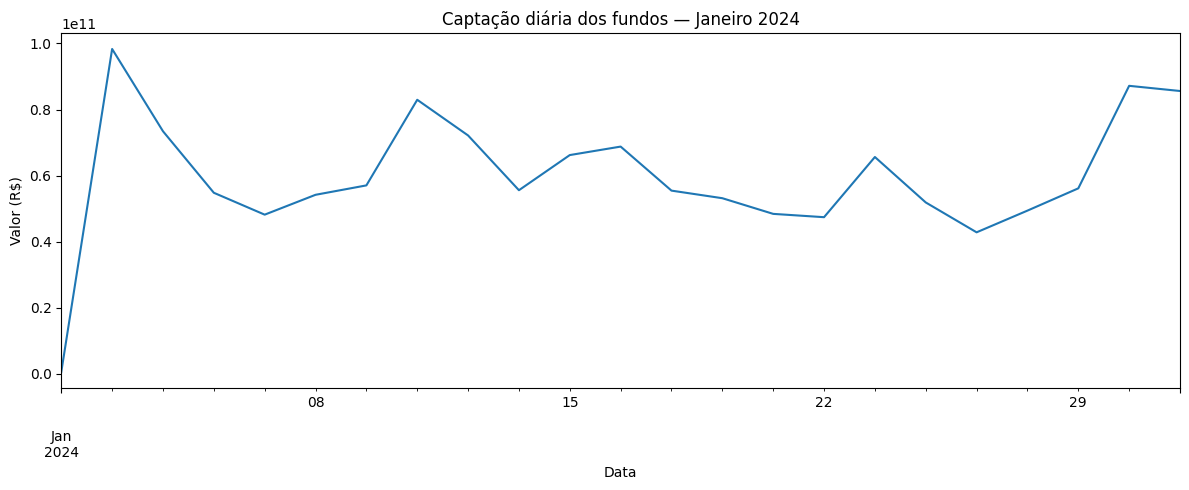

In [9]:
plt.figure(figsize=(12, 5))
df.groupby("DT_COMPTC")["CAPTC_DIA"].sum().plot()
plt.title("Captação diária dos fundos — Janeiro 2024")
plt.xlabel("Data")
plt.ylabel("Valor (R$)")
plt.tight_layout()
plt.show()

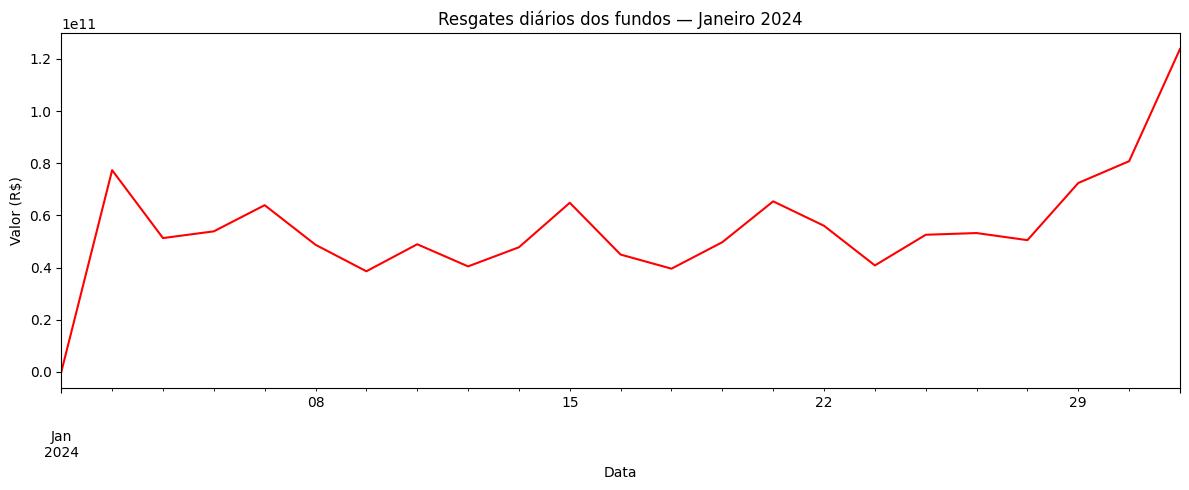

In [10]:
plt.figure(figsize=(12, 5))
df.groupby("DT_COMPTC")["RESG_DIA"].sum().plot(color="red")
plt.title("Resgates diários dos fundos — Janeiro 2024")
plt.xlabel("Data")
plt.ylabel("Valor (R$)")
plt.tight_layout()
plt.show()

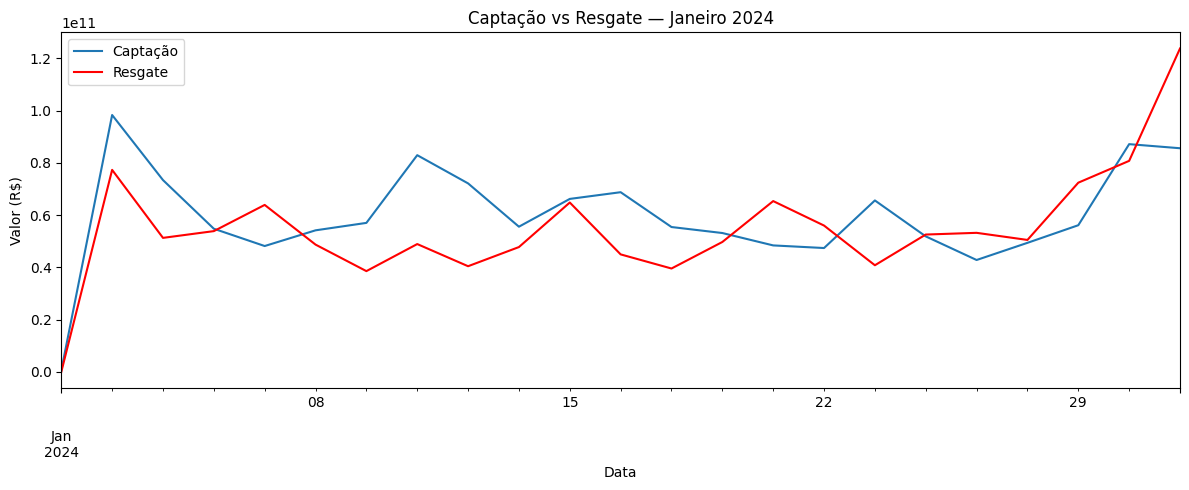

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
df.groupby("DT_COMPTC")["CAPTC_DIA"].sum().plot(ax=ax, label="Captação")
df.groupby("DT_COMPTC")["RESG_DIA"].sum().plot(ax=ax, label="Resgate", color="red")
plt.title("Captação vs Resgate — Janeiro 2024")
plt.xlabel("Data")
plt.ylabel("Valor (R$)")
plt.legend()
plt.tight_layout()
plt.show()